# Train Phase 1 ML Baselines (Colab)

## Data

## Evaluation

## Configuration

In [1]:
from pathlib import Path
import json
import pickle
import gc
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve

SEED = 42
np.random.seed(SEED)

HELD_OUT_FAMILY = 'Heartbleed'
CIC_CSV_FOLDER = 'cic_ids_data'
MAX_TOTAL_ROWS = 900_000
MAX_BENIGN_FRACTION = 0.70
MAX_BENIGN_TRAIN_ROWS = 180_000
OCSVM_TRAIN_ROWS = 80_000
CHUNK_ROWS = 100_000

DRIVE_MY = Path('/content/drive/MyDrive')
try:
    from google.colab import drive
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

if RUNNING_IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    DATA_DIR = (DRIVE_MY / CIC_CSV_FOLDER).resolve()
    OUT_DIR = (DRIVE_MY / 'cic_ids_outputs' / 'phase1_ml').resolve()
else:
    DATA_DIR = (Path.cwd().resolve() / 'data' / 'cic_ids').resolve()
    OUT_DIR = (Path.cwd().resolve() / 'models' / 'phase1_ml').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)
print('DATA_DIR =', DATA_DIR)
print('OUT_DIR  =', OUT_DIR)

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive/cic_ids_data
OUT_DIR  = /content/drive/MyDrive/cic_ids_outputs/phase1_ml


## Validate CSV files

In [2]:
CIC_DAY_FILES = (
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
)

if not DATA_DIR.is_dir():
    raise FileNotFoundError(f'DATA_DIR missing: {DATA_DIR}')
missing = [n for n in CIC_DAY_FILES if not (DATA_DIR / n).is_file()]
if missing:
    raise FileNotFoundError('Missing files:\n- ' + '\n- '.join(missing))
print('All required files are present.')

All required files are present.


## Load CIC-IDS with chunked serious sampling

In [3]:
def normalize_attack_family(label: str) -> str:
    s = str(label).strip().replace('\x00', '')
    low = s.lower()
    if low == 'benign': return 'Benign'
    if 'heartbleed' in low: return 'Heartbleed'
    if 'web attack' in low or 'webattack' in low: return 'WebAttack'
    if 'portscan' in low: return 'PortScan'
    if 'dos' in low and 'ddos' not in low: return 'DoS'
    if 'ddos' in low: return 'DDoS'
    if 'bot' in low: return 'Bot'
    if 'infiltration' in low: return 'Infiltration'
    return s

rng = np.random.default_rng(SEED)
target_total = int(MAX_TOTAL_ROWS) if MAX_TOTAL_ROWS else None
target_benign = None if target_total is None else int(target_total * MAX_BENIGN_FRACTION)
per_file_benign_target = None if target_benign is None else math.ceil(target_benign / len(CIC_DAY_FILES))

benign_parts, attack_parts = [], []
for name in CIC_DAY_FILES:
    p = DATA_DIR / name
    kept_benign = kept_attack = 0
    for chunk in pd.read_csv(p, low_memory=True, chunksize=CHUNK_ROWS):
        chunk.columns = [c.strip() for c in chunk.columns]
        raw = chunk['Label'].astype(str).str.strip()
        y = (raw.str.lower() != 'benign').astype(np.int8)
        fam = raw.map(normalize_attack_family)

        x = chunk.drop(columns=['Label'], errors='ignore').select_dtypes(include=[np.number])
        if x.empty:
            continue
        x = x.replace([np.inf, -np.inf], np.nan).astype(np.float32, copy=False)
        x['y'] = y.values
        x['attack_family'] = fam.values

        atk = x[x['y'] == 1]
        if len(atk):
            attack_parts.append(atk.copy())
            kept_attack += len(atk)

        ben = x[x['y'] == 0]
        if len(ben):
            if per_file_benign_target is None:
                take = ben
            else:
                rem = per_file_benign_target - kept_benign
                if rem <= 0:
                    take = None
                else:
                    n_take = min(rem, len(ben))
                    if n_take < len(ben):
                        idx = rng.choice(len(ben), size=n_take, replace=False)
                        take = ben.iloc[idx].copy()
                    else:
                        take = ben.copy()
            if take is not None and len(take):
                benign_parts.append(take)
                kept_benign += len(take)

    print(f'loaded {name}: benign={kept_benign:,}, attacks={kept_attack:,}')
    gc.collect()

benign_df = pd.concat(benign_parts, ignore_index=True) if benign_parts else pd.DataFrame()
attack_df = pd.concat(attack_parts, ignore_index=True) if attack_parts else pd.DataFrame()

if target_total:
    if len(attack_df) >= target_total:
        clean = attack_df.sample(n=target_total, random_state=SEED).reset_index(drop=True)
    else:
        n_ben = max(0, target_total - len(attack_df))
        if len(benign_df) > n_ben:
            benign_df = benign_df.sample(n=n_ben, random_state=SEED).reset_index(drop=True)
        clean = pd.concat([benign_df, attack_df], ignore_index=True)
else:
    clean = pd.concat([benign_df, attack_df], ignore_index=True)

clean = clean.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
feature_cols = [c for c in clean.columns if c not in {'y', 'attack_family'}]
clean[feature_cols] = clean[feature_cols].fillna(clean[feature_cols].median(numeric_only=True))
print('Rows:', len(clean), 'Features:', len(feature_cols))
print(clean['attack_family'].value_counts().to_string())

loaded Monday-WorkingHours.pcap_ISCX.csv: benign=78,750, attacks=0
loaded Tuesday-WorkingHours.pcap_ISCX.csv: benign=78,750, attacks=13,835
loaded Wednesday-workingHours.pcap_ISCX.csv: benign=78,750, attacks=252,672
loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: benign=78,750, attacks=2,180
loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: benign=78,750, attacks=36
loaded Friday-WorkingHours-Morning.pcap_ISCX.csv: benign=78,750, attacks=1,966
loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: benign=78,750, attacks=158,930
loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: benign=78,750, attacks=128,027
Rows: 900000 Features: 78
attack_family
Benign          342354
DoS             252661
PortScan        158930
DDoS            128027
FTP-Patator       7938
SSH-Patator       5897
WebAttack         2180
Bot               1966
Infiltration        36
Heartbleed          11


## Split and scale

In [4]:
features = [c for c in clean.columns if c not in {'y', 'attack_family'}]
benign = clean[clean['y'] == 0]
attacks = clean[clean['y'] == 1]
held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]
if len(held) == 0 and len(attacks) > 0:
    HELD_OUT_FAMILY = attacks['attack_family'].value_counts().index[0]
    held = attacks[attacks['attack_family'] == HELD_OUT_FAMILY]
    known = attacks[attacks['attack_family'] != HELD_OUT_FAMILY]

b_tr, b_tmp = train_test_split(benign, test_size=0.30, random_state=SEED)
b_val, b_te = train_test_split(b_tmp, test_size=2/3, random_state=SEED)

te_known = pd.concat([b_te, known], ignore_index=True).sample(frac=1.0, random_state=SEED)
te_zero = pd.concat([b_te, held], ignore_index=True).sample(frac=1.0, random_state=SEED)

X_train = b_tr[features].to_numpy(dtype=np.float32)
X_val = b_val[features].to_numpy(dtype=np.float32)
X_known = te_known[features].to_numpy(dtype=np.float32)
y_known = te_known['y'].to_numpy(dtype=np.int8)
X_zero = te_zero[features].to_numpy(dtype=np.float32)
y_zero = te_zero['y'].to_numpy(dtype=np.int8)

if MAX_BENIGN_TRAIN_ROWS and len(X_train) > MAX_BENIGN_TRAIN_ROWS:
    idx = np.random.default_rng(SEED).choice(len(X_train), size=MAX_BENIGN_TRAIN_ROWS, replace=False)
    X_train = X_train[idx]

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_known_s = scaler.transform(X_known)
X_zero_s = scaler.transform(X_zero)

if OCSVM_TRAIN_ROWS and len(X_train_s) > OCSVM_TRAIN_ROWS:
    idx = np.random.default_rng(SEED + 1).choice(len(X_train_s), size=OCSVM_TRAIN_ROWS, replace=False)
    X_train_ocsvm = X_train_s[idx]
else:
    X_train_ocsvm = X_train_s

print('train:', X_train_s.shape, 'ocsvm train:', X_train_ocsvm.shape, 'held:', HELD_OUT_FAMILY)

train: (180000, 78) ocsvm train: (80000, 78) held: Heartbleed


## Train ML models

In [5]:
iso = IsolationForest(n_estimators=500, contamination=0.01, random_state=SEED, n_jobs=-1)
iso.fit(X_train_s)

ocsvm = OneClassSVM(kernel='rbf', nu=0.03, gamma='scale')
ocsvm.fit(X_train_ocsvm)

iso_val = -iso.score_samples(X_val_s)
svm_val = -ocsvm.decision_function(X_val_s)
iso_known = -iso.score_samples(X_known_s)
svm_known = -ocsvm.decision_function(X_known_s)
iso_zero = -iso.score_samples(X_zero_s)
svm_zero = -ocsvm.decision_function(X_zero_s)
print('Models trained.')

Models trained.


## Evaluate metrics

In [6]:
def eval_metrics(y_true, score, thr):
    pred = (score >= thr).astype(np.int8)
    return {
        'roc_auc': float(roc_auc_score(y_true, score)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
    }

iso_thr = float(np.quantile(iso_val, 0.99))
svm_thr = float(np.quantile(svm_val, 0.99))
results = {
    'IsolationForest_test_known': eval_metrics(y_known, iso_known, iso_thr),
    'IsolationForest_test_zero_day': eval_metrics(y_zero, iso_zero, iso_thr),
    'OneClassSVM_test_known': eval_metrics(y_known, svm_known, svm_thr),
    'OneClassSVM_test_zero_day': eval_metrics(y_zero, svm_zero, svm_thr),
}
for k, v in results.items():
    print('\n', k)
    for m, s in v.items():
        print(f'  {m}: {s:.4f}')


 IsolationForest_test_known
  roc_auc: 0.6984
  precision: 0.9329
  recall: 0.0144
  f1: 0.0284

 IsolationForest_test_zero_day
  roc_auc: 0.9996
  precision: 0.0186
  recall: 1.0000
  f1: 0.0366

 OneClassSVM_test_known
  roc_auc: 0.7588
  precision: 0.9972
  recall: 0.4124
  f1: 0.5835

 OneClassSVM_test_zero_day
  roc_auc: 0.9995
  precision: 0.0168
  recall: 1.0000
  f1: 0.0330


## ROC plots

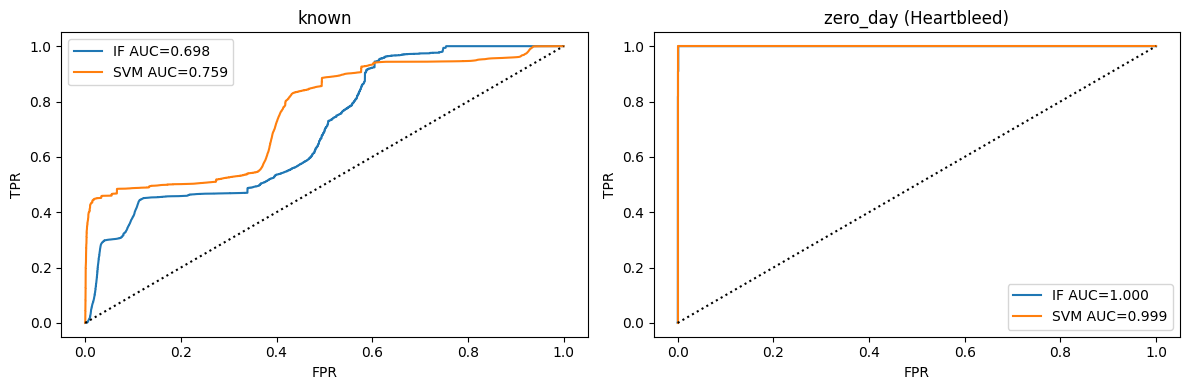

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y, s1, s2, title in [
    (axes[0], y_known, iso_known, svm_known, 'known'),
    (axes[1], y_zero, iso_zero, svm_zero, f'zero_day ({HELD_OUT_FAMILY})'),
]:
    fpr1, tpr1, _ = roc_curve(y, s1)
    fpr2, tpr2, _ = roc_curve(y, s2)
    ax.plot(fpr1, tpr1, label=f'IF AUC={roc_auc_score(y, s1):.3f}')
    ax.plot(fpr2, tpr2, label=f'SVM AUC={roc_auc_score(y, s2):.3f}')
    ax.plot([0,1],[0,1],'k:')
    ax.set_title(title); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend()
plt.tight_layout(); plt.show()

## Save artifacts

In [8]:
artifact = {
    'features': features,
    'held_out_family': HELD_OUT_FAMILY,
    'isolation_forest': iso,
    'one_class_svm': ocsvm,
    'scaler': scaler,
    'iso_threshold': iso_thr,
    'svm_threshold': svm_thr,
    'results': results,
}

pth = OUT_DIR / 'phase1_ml_model.pth'
json_path = OUT_DIR / 'phase1_ml_results.json'
with open(pth, 'wb') as f:
    pickle.dump(artifact, f)
json_path.write_text(json.dumps(results, indent=2))
print('Saved:', pth)
print('Saved:', json_path)

Saved: /content/drive/MyDrive/cic_ids_outputs/phase1_ml/phase1_ml_model.pth
Saved: /content/drive/MyDrive/cic_ids_outputs/phase1_ml/phase1_ml_results.json


## Artifact

## End